# 2d. WTI Crude Oil Meta-Model
### WTI Crude Oil Futures (cl1s)

In this notebook we develop the meta-model for WTI crude oil (cl1s). Meta-labelling uses a secondary model to decide whether to act on a primary model's signal. The primary signal says which way to trade, and the meta-model gives each of those signals a probability of being a genuine opportunity rather than noise.

We start from the assembled feature matrix built in notebook 1, which gives every instrument a common set of base features. On top of that we add a few WTI crude oil specific features, the latent regime features, and the primary-signal features, then reduce everything with PCA, label the trades with the triple-barrier method, and compare a range of models. Every feature is strictly backward looking, so nothing here uses information from the future.

## 1. Imports

We load the standard scientific Python stack together with scikit-learn, XGBoost and Keras. These cover the data handling, the classical models, and the neural networks used later on.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import xgboost as xgb

np.random.seed(42)

## 2. Load the Feature Matrix

We load the assembled feature matrix and, for WTI crude oil, add the more specific data on top before running the triple-barrier method and the HMM for the regime state. The base features were built in the feature engineering notebook, and the idea is to keep a common set of base features that we can then enrich, so the meta-model has both general and WTI crude oil specific information to work with.

In [ ]:
features = pd.read_parquet('../data/processed/features/features.parquet')
features['date'] = pd.to_datetime(features['date'])
feat_dict = pd.read_csv('../data/processed/features/feature_dictionary.csv')

print('Shape:', features.shape)
print('Date range:', features['date'].min().date(), '→', features['date'].max().date())
print('Instruments:', sorted(features['instrument'].unique()))
print('Feature columns:', len(features.columns) - 3)  # minus date, instrument, primary_signal

In [ ]:
# Quick look at what we have, grouped by course bucket
feat_dict.groupby('course_bucket').size().sort_values(ascending=False)

## 3. Tier 1: Base Features

We keep the WTI crude oil rows (cl1s), sort them by date, and recap the Tier 1 base features. These are the general price and volatility features that apply to any instrument, such as returns, momentum, rolling volatility, and the trend-scanning t-statistics. They describe what prices have actually done and form the backbone that the later tiers build on.

In [ ]:
wti = features[features['instrument'] == 'cl1s'].set_index('date').sort_index().copy()
print(wti.shape)
wti.head()

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(wti.index, wti['logret_1d'])
plt.title('WTI crude oil (cl1s) log returns')
plt.grid(True)
plt.show()

In [ ]:
base_cols = [
    'logret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d',
    'vol_20d', 'vol_60d', 'parkinson_20d', 'garman_klass_20d',
    'vol_of_vol_20d', 'vol_ratio_5_60',
    'volume_z_20d', 'oi_z_60d', 'oi_change_5d', 'volume_oi_ratio',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width_20', 'bb_pos_20', 'atr_14', 'adx_14',
    'dd_from_60d_high', 'runup_from_60d_low', 'days_since_60d_high',
    'trend_tstat_10', 'trend_tstat_20', 'trend_tstat_60',
    'trend_tstat_best', 'trend_H_best',
]
wti[base_cols].tail()

In [ ]:
# Trend-scanning t-stats, Lecture 1, max |t| over several horizons
fig, ax = plt.subplots(figsize=(12, 4))
for h in [10, 20, 60]:
    ax.plot(wti.index, wti[f'trend_tstat_{h}'], label=f'H={h}', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('WTI trend-scanning t-statistics')
ax.legend()
ax.grid(True)
plt.show()

## 4. Tier 2: Energy-Specific Features

Tier 2 adds features that are specific to the energy complex, for example crack spreads and cross-instrument spreads. Meta-labelling uses a secondary model to decide whether to act on the primary model's signal, and these features give that secondary model the energy-market context that a generic price feature would miss.

In [ ]:
energy_cols = [
    'energy_basket_ret_5d', 'energy_basket_vol_20d',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'crack_321_proxy', 'crack_321_z_60d',
    'ho_cl_spread', 'rb_cl_spread',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'winter_indicator', 'driving_season',
]
wti[energy_cols].tail()

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(wti.index, wti['crack_321_z_60d'], color='tab:red', label='crack 60d z')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_ylabel('crack_321_z_60d')
ax1.set_title('WTI: 3-2-1 crack spread z-score (60d)')
ax1.grid(True)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wti.index, wti['ho_cl_spread'], label='HO/CL log-spread')
ax.plot(wti.index, wti['rb_cl_spread'], label='RB/CL log-spread')
ax.set_title('Product-vs-crude log spreads (seasonal)')
ax.legend()
ax.grid(True)
plt.show()

### 4.1 OVX Implied-Volatility Features

OVX is the CBOE Crude Oil Volatility Index, the implied-vol surface for USO options and the oil-market analogue of VIX. It is a forward-looking measure of expected WTI volatility, useful alongside the backward-looking `vol_20d`, `parkinson_20d`, and related features.

In this section we compute the following:
- `ovx_close` daily close
- `ovx_z` z-score on a 63-day window
- `iv_rv_ratio` implied vol (OVX) divided by realised vol (21-day annualised, in vol points)
- `ovx_slope` 5-day percentage change

**Why these features matter for meta-labelling**

The core idea is that options markets price in information that price-based features miss. When OVX is elevated, the market is paying up for crash protection, which usually means someone knows something or at least fears something. That is exactly the regime where a trend-following primary signal is most likely to get whipsawed.

`ovx_close` gives the raw implied vol level. On its own it is noisy, but it tells the meta-model whether the market is broadly calm or stressed. A bullish WTI crude oil signal fired into a 50 plus OVX reading deserves a lot more scepticism than the same signal at OVX 25.

`ovx_z` normalises that level against the past 63 days. An OVX of 35 is unremarkable in a high-vol year but extreme in a quiet one. The z-score is what tells the meta-model whether the market is unusually fearful relative to its recent baseline, which is the number that matters for confidence calibration.

`iv_rv_ratio` is the most informative of the four. When implied vol runs well above realised vol, options are expensive and the market is pricing in a jump that has not happened yet. That tends to mean either a real catalyst is coming or the market is being irrational, and either way signal quality drops. When IV is below RV, options are cheap, the market has stopped hedging, and price action tends to be cleaner and more trend-friendly. The ratio is a direct read on how much the market trusts its own price signals.

`ovx_slope` captures whether fear is building or fading. A sharply rising OVX over 5 days, even from a moderate level, often precedes the kind of volatile, choppy price action that kills quantitative signals. A falling OVX after a spike is the opposite, the market is calming down and directional signals start working again. The slope gives the meta-model a sense of direction, not just level.

In [ ]:
def load_ovx():
    """Return OVX close series indexed by date, or None if unavailable."""
    local = '../data/src/ovx.csv'
    df = pd.read_csv(local)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    close_col = 'Close' if 'Close' in df.columns else 'close'
    df[date_col] = pd.to_datetime(df[date_col])
    return df.set_index(date_col)[close_col].rename('ovx_close').sort_index()


ovx_close = load_ovx()
if ovx_close is not None:
    ovx_close.index = pd.to_datetime(ovx_close.index).tz_localize(None)
    print('OVX rows:', len(ovx_close),
          'range:', ovx_close.index.min().date(), '→', ovx_close.index.max().date())
else:
    print('No OVX data available, subsequent OVX cells will be skipped.')

In [ ]:
if ovx_close is not None:
    ovx = ovx_close.to_frame()
    ovx['ovx_z'] = (
        (ovx['ovx_close'] - ovx['ovx_close'].rolling(63).mean())
        / ovx['ovx_close'].rolling(63).std()
    )
    ovx['ovx_slope'] = ovx['ovx_close'].pct_change(5)

    # iv_rv_ratio: implied (OVX, already in annualised vol points) over realised.
    # vol_20d is the std of daily logret, annualise by sqrt(252) and scale by 100 for vol points.
    rv_pts = wti['vol_20d'] * np.sqrt(252) * 100
    ovx['iv_rv_ratio'] = ovx['ovx_close'] / rv_pts.reindex(ovx.index)

    wti = wti.join(ovx[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']], how='left')
    print(wti[['ovx_close', 'ovx_z', 'iv_rv_ratio', 'ovx_slope']].dropna().tail())
else:
    print('Skipped: OVX not loaded.')

In [ ]:
if 'ovx_close' in wti.columns and wti['ovx_close'].notna().any():
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(wti.index, wti['ovx_close'], label='OVX')
    axes[0].set_title('OVX (crude oil implied vol)')
    axes[0].grid(True); axes[0].legend()
    axes[1].plot(wti.index, wti['iv_rv_ratio'], label='IV / RV', color='tab:orange')
    axes[1].axhline(1.0, color='k', lw=0.5)
    axes[1].set_title('Implied / realised vol ratio (>1 ⇒ market pricing more risk than recently realised)')
    axes[1].grid(True); axes[1].legend()
    plt.tight_layout()
    plt.show()

## 5. Tier 3: Latent Features

These are the latent regime features learned in notebook 1. They infer the hidden state the market is in rather than just describing what prices did.

**GMM**: a 3-component Gaussian mixture on `[vol_20d, vol_of_vol_20d, parkinson_20d]`, refit walk-forward every 63 trading days with a 504-day warmup. The components are re-sorted by mean vol after every refit, so `gmm_resp_low_vol` always means low vol regardless of how a refit shuffles the labels.

**HMM**: a 2-state Gaussian HMM (calm and turbulent) on `[logret_1d, vol_20d]`, trained walk-forward on the same schedule. We use filtering, not smoothing, so `hmm_filt_*` at time `t` only depends on data up to `t`. Calling `predict_proba` on a fitted HMM runs forward-backward and uses future data inside the training window, and we deliberately do not do that. `hmm_next_turbulent` is a one-step-ahead forecast, `hmm_regime_age` is the number of days since the regime last switched, and `hmm_basket_turbulent_energy` runs the same logic across the whole energy complex.

**K-means**: K=3 on the cross-section `[ret_5d, vol_20d, volume_z_20d]` of the energy complex per day. `kmeans_cluster_size` is the fraction of instruments sharing the same cluster, so a value near 1.0 means the whole complex is co-moving while a value near 0.25 means the instruments are behaving independently.


In [ ]:
latent_cols = [
    'gmm_resp_low_vol', 'gmm_resp_med_vol', 'gmm_resp_high_vol', 'gmm_max_resp',
    'hmm_filt_calm', 'hmm_filt_turbulent', 'hmm_next_turbulent', 'hmm_regime_age',
    'hmm_basket_turbulent_energy',
    'kmeans_cluster_id', 'kmeans_cluster_size',
]
wti[latent_cols].tail()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(wti.index, wti['hmm_filt_turbulent'], label='p(turbulent | x_{1:t})')
axes[0].plot(wti.index, wti['hmm_next_turbulent'], label='p(turbulent at t+1)', alpha=0.6)
axes[0].set_title('WTI HMM filtering posteriors (no leakage)')
axes[0].legend(); axes[0].grid(True)

axes[1].stackplot(wti.index,
                  wti['gmm_resp_low_vol'].fillna(0),
                  wti['gmm_resp_med_vol'].fillna(0),
                  wti['gmm_resp_high_vol'].fillna(0),
                  labels=['low', 'med', 'high'], alpha=0.7)
axes[1].set_title('WTI GMM responsibilities (walk-forward, label-stable)')
axes[1].legend(loc='upper right'); axes[1].grid(True)
plt.tight_layout()
plt.show()

## 6. Tier 4: Primary Signal Features

Tier 4 describes the primary signal itself, including its direction, its recent lags, and how long it has been firing the same way. The meta-model needs to know what the primary strategy is doing before it can judge whether to back it.

In [ ]:
sig_cols = [
    'primary_signal',
    'primary_signal_lag1', 'primary_signal_lag5',
    'primary_signal_streak'
]
wti[sig_cols].dropna().head(10)

## 7. Dimensionality Reduction and Regime Filtering

Here we handle the downstream steps. We split the data at the signal start date, group the correlated features into clusters, reduce each cluster to a single factor with a within-cluster principal component, add the forward-only HMM regime probabilities, and pass the result to the models. The aim is to cut the feature count down to a small set of interpretable factors so the model stays stable on a small sample and we can still say which feature group drives it.

**Why clustering rather than a single global PCA**

With many more candidate features than labelled rows, some dimensionality control is needed or the model overfits. A global PCA would do that, but it rotates every feature into dense components, so the inputs stop being interpretable and the leading components can be dominated by whichever block of features happens to carry the most variance. Grouping correlated features and taking one principal component within each group gives the same denoising and an even smaller feature count, while keeping every factor tied to a named theme. That interpretability is exactly what the cluster-level importance analysis later in the project depends on.

**Filtering over smoothing**

The HMM that runs on these factors uses the forward algorithm only. The forward-backward algorithm that standard implementations use for `predict_proba` is a smoother, so the probability assigned to time `t` depends on observations both before and after `t`. That is fine for offline analysis but fatal for a trading model, since it means today's regime label was partly determined by tomorrow's returns. Using the forward pass only means the regime probabilities are genuine real-time estimates.

**Why a 70/30 train/test split**

The split is reserved purely for final evaluation, the test set is never touched during tuning. The primary signal data begins in 2020, but the feature pipeline has a 504-day warmup before the first GMM, HMM, and PCA refit fires, which consumes roughly two years before a single fully-featured labelled observation is available. That is why `SIGNAL_START = '2021-08-16'` sits where it does, and a 70/30 split on that effective window gives roughly two years of training and just under one year of test data. Triple-barrier labelling shrinks the sample further, since it only fires when the primary signal is non-zero and many entries hit the time barrier, so going to 80/20 would push the test set down to a point where the standard error of AUC is nearly as wide as the signal itself. The 5-fold walk-forward CV on the training set does the heavy lifting for model selection, and a 70% training allocation gives each fold enough data to produce a meaningful AUC estimate.

The honest limitation is that a single temporal split means the test set covers one specific market period. If that period happens to be unusually calm or unusually stressed, the test AUC will not reflect long-run performance. The right way to read the results is as how the meta-model would have performed had it gone live at the split date, not as a claim about universal performance.

In [ ]:
SIGNAL_START = '2021-08-16'

# Feature set fed into the clustering and the downstream models.
# Base and energy features, plus OVX, plus the Tier 3 latent and Tier 4 signal features.
downstream_cols = [
    'logret_1d', 'vol_20d', 'vol_60d', 'parkinson_20d',
    'ret_5d', 'ret_20d', 'ret_60d',
    'rsi_14', 'macd_hist', 'bb_pos_20', 'adx_14',
    'dd_from_60d_high', 'trend_tstat_best',
    'crack_321_z_60d', 'ho_cl_spread', 'rb_cl_spread',
    'rel_ret_vs_basket_5d', 'corr_to_basket_60d',
    'winter_indicator', 'driving_season',
]

# Add OVX columns if they were loaded in section 4.1
ovx_cols = [c for c in ['ovx_z', 'iv_rv_ratio', 'ovx_slope'] if c in wti.columns]
if ovx_cols:
    downstream_cols += ovx_cols
    print('Including OVX features:', ovx_cols)

# Add the Tier 3 latent regime features and the Tier 4 primary-signal features.
downstream_cols += [c for c in latent_cols + sig_cols if c in wti.columns]

X = wti[downstream_cols].dropna()

X_train = X.loc[X.index <  SIGNAL_START]
X_test  = X.loc[X.index >= SIGNAL_START]

print('train:', X_train.shape, 'test:', X_test.shape, '| features:', len(downstream_cols))

### 7.1 Feature Clustering

Instead of one PCA over the whole feature set, we group the features by how correlated they are, so each group can later be summarised and interrogated as a unit. We measure similarity with the Spearman correlation, which is robust to the fat tails in return data, and convert it to the Lopez de Prado distance `d = sqrt(0.5 (1 - rho))`, which is a proper metric. We then run average-linkage hierarchical clustering and cut the tree at a correlation threshold, so two features only share a cluster if they are genuinely correlated.

The silhouette curve here is flat, which tells us there is no single best number of clusters, so picking a fixed k would force unrelated features together and leave clusters that one principal component cannot summarise well. Cutting at a correlation level instead respects the real structure and keeps every cluster tight, so its first principal component stays a faithful summary. `CORR_THRESHOLD` is the one knob, raise it for tighter and more numerous groups, lower it for fewer and broader ones. Everything here is fit on the training window only, and the silhouette curve and dendrogram are shown as diagnostics.

In [ ]:
# Cluster the features by their correlation, on the training window only (no leakage).
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# keep only features that actually vary in the training window
cluster_feats = [c for c in X_train.columns if X_train[c].std() > 0]

# Spearman correlation -> Lopez de Prado distance d = sqrt(0.5 (1 - rho))
corr = X_train[cluster_feats].corr(method='spearman')
dist = np.sqrt(0.5 * (1 - corr)).clip(lower=0)
Z = linkage(squareform(dist.values, checks=False), method='average')

# Cut the tree at a correlation threshold, so features only share a cluster if they
# are genuinely correlated. Raise CORR_THRESHOLD for tighter, more numerous groups,
# lower it for fewer, broader ones.
CORR_THRESHOLD = 0.4
dist_cut = np.sqrt(0.5 * (1 - CORR_THRESHOLD))
cluster_id = pd.Series(fcluster(Z, dist_cut, criterion='distance'),
                       index=cluster_feats, name='cluster')
print(f'CORR_THRESHOLD = {CORR_THRESHOLD}  ->  {cluster_id.nunique()} clusters')

# Silhouette curve, kept only as a diagnostic. A flat curve means there is no single best k.
sil = {}
for k in range(2, min(11, len(cluster_feats))):
    labels_k = fcluster(Z, k, criterion='maxclust')
    if len(np.unique(labels_k)) < 2:
        continue
    sil[k] = silhouette_score(dist.values, labels_k, metric='precomputed')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(sil.keys()), list(sil.values()), marker='o')
ax[0].set_xlabel('number of clusters')
ax[0].set_ylabel('silhouette')
ax[0].set_title('Silhouette vs k (diagnostic)')
dendrogram(Z, labels=cluster_feats, ax=ax[1], leaf_rotation=90, color_threshold=dist_cut)
ax[1].axhline(dist_cut, color='red', ls='--', lw=0.8, label=f'cut at rho = {CORR_THRESHOLD}')
ax[1].legend()
ax[1].set_title('Feature dendrogram (Spearman distance)')
plt.tight_layout()
plt.show()

### 7.2 Cluster Composition and Names

We list the features in each cluster and attach a readable name from the dominant theme of its members, for example volatility, momentum, energy spreads or implied vol. The names are only a suggestion, the `cluster_names` dictionary can be edited if a label does not fit. These names carry through to the factor columns and to the cluster-level importance analysis later on.

In [ ]:
# Show the members of each cluster and auto-suggest a readable name from the dominant theme.
THEME = {
    'logret_1d': 'returns', 'ret_5d': 'returns', 'ret_20d': 'returns', 'ret_60d': 'returns',
    'vol_20d': 'volatility', 'vol_60d': 'volatility', 'parkinson_20d': 'volatility', 'vol_of_vol_20d': 'volatility',
    'rsi_14': 'oscillators', 'macd_hist': 'oscillators', 'bb_pos_20': 'oscillators',
    'adx_14': 'trend', 'trend_tstat_best': 'trend', 'dd_from_60d_high': 'drawdown',
    'crack_321_z_60d': 'energy_spreads', 'ho_cl_spread': 'energy_spreads', 'rb_cl_spread': 'energy_spreads',
    'rel_ret_vs_basket_5d': 'cross_sectional', 'corr_to_basket_60d': 'cross_sectional',
    'winter_indicator': 'seasonality', 'driving_season': 'seasonality',
    'ovx_z': 'implied_vol', 'iv_rv_ratio': 'implied_vol', 'ovx_slope': 'implied_vol',
    'gmm_resp_low_vol': 'regime', 'gmm_resp_med_vol': 'regime', 'gmm_resp_high_vol': 'regime', 'gmm_max_resp': 'regime',
    'hmm_filt_calm': 'regime', 'hmm_filt_turbulent': 'regime', 'hmm_next_turbulent': 'regime',
    'hmm_regime_age': 'regime', 'hmm_basket_turbulent_energy': 'regime',
    'kmeans_cluster_id': 'regime', 'kmeans_cluster_size': 'regime',
    'primary_signal': 'signal', 'primary_signal_lag1': 'signal', 'primary_signal_lag5': 'signal', 'primary_signal_streak': 'signal',
}

cluster_names, used = {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    themes = pd.Series([THEME.get(m, 'other') for m in members]).value_counts()
    name = themes.index[0]
    if len(themes) > 1 and themes.iloc[1] == themes.iloc[0]:
        name = f'{themes.index[0]}_{themes.index[1]}'   # tie, combine the top two themes
    used[name] = used.get(name, 0) + 1
    if used[name] > 1:
        name = f'{name}_{used[name]}'                    # keep the names unique
    cluster_names[c] = name
    print(f'cluster {c:>2}  ->  {name:<22} {members}')

# Edit cluster_names here if any auto-suggested label does not fit.

### 7.3 Within-Cluster PC1

Each cluster is reduced to a single factor, the first principal component taken within that cluster. This keeps the denoising benefit of PCA but ties every factor to one named group, so we can still say which group drives the model. We sign-align each component to its cluster mean so a higher value has a consistent meaning, and we report how much of the cluster variance the first component captures. The scaler and the components are fit on the training window and then applied to the test window.

In [ ]:
# Reduce each cluster to a single factor, the first principal component within that cluster.
# The scaler, the clustering and the sign alignment are all fit on the training window only.
scaler = StandardScaler()
Xtr_s = pd.DataFrame(scaler.fit_transform(X_train[cluster_feats]), index=X_train.index, columns=cluster_feats)
Xte_s = pd.DataFrame(scaler.transform(X_test[cluster_feats]),      index=X_test.index,  columns=cluster_feats)

cluster_pca, evr, train_fac, test_fac = {}, {}, {}, {}
for c in sorted(cluster_id.unique()):
    members = list(cluster_id[cluster_id == c].index)
    p = PCA(n_components=1, random_state=42)
    tr = p.fit_transform(Xtr_s[members]).ravel()
    te = p.transform(Xte_s[members]).ravel()
    if np.corrcoef(tr, Xtr_s[members].mean(axis=1))[0, 1] < 0:   # sign-align to the cluster mean
        tr, te = -tr, -te
    name = cluster_names[c]
    train_fac[name], test_fac[name] = tr, te
    evr[name] = p.explained_variance_ratio_[0]
    cluster_pca[c] = p

train_pca_df = pd.DataFrame(train_fac, index=X_train.index)
test_pca_df  = pd.DataFrame(test_fac,  index=X_test.index)
X_train_pca, X_test_pca = train_pca_df.values, test_pca_df.values
pc_cols = list(train_pca_df.columns)

print('cluster factors:', pc_cols)
print('PC1 variance explained per cluster:', {k: round(v, 2) for k, v in evr.items()})
print(f'reduced from {len(cluster_feats)} features to {len(pc_cols)} cluster factors')
train_pca_df.head()

### 7.4 HMM Regime Filtering

We choose the number of hidden states with a BIC sweep, fitting candidate models with 2 to 5 states and several random seeds and keeping the lowest BIC. We then run the forward algorithm by hand to obtain filtering posteriors on the cluster factors. Filtering uses only past and present data, unlike the smoothing that `predict_proba` would apply, so the regime probabilities that feed the meta-model stay free of look-ahead. We also compute a one-step-ahead forecast by pushing the current filtered state through the transition matrix.

In [ ]:
# BIC sweep for the optimal number of HMM states, capped at 5

def hmm_bic(model, X):
    K = model.n_components
    T, d = X.shape
    logL = model.score(X)
    k_params = (K - 1) + K * (K - 1) + K * (2 * d)
    return -2 * logL + k_params * np.log(T), logL

best = {'bic': np.inf, 'hmm': None, 'K': None}
for K in range(2, 6):
    best_for_K = {'bic': np.inf, 'hmm': None}
    for seed in range(10):
        h = GaussianHMM(n_components=K, covariance_type='diag',
                        n_iter=1000, random_state=42 + seed)
        try:
            h.fit(X_train_pca)
            bic, _ = hmm_bic(h, X_train_pca)
            if bic < best_for_K['bic']:
                best_for_K = {'bic': bic, 'hmm': h}
        except Exception:
            continue
    print(f'K={K}: BIC={best_for_K["bic"]:,.1f}')
    if best_for_K['bic'] < best['bic']:
        best = {'bic': best_for_K['bic'], 'hmm': best_for_K['hmm'], 'K': K}

print('Chosen K =', best['K'])

In [ ]:
# IMPORTANT: predict_proba runs forward-backward (smoothing) which uses future
# data inside the train window. For meta-model features we want filtering only.
# Below: filtering posteriors via the forward algorithm.

def hmm_filter(model, X):
    """Forward-only filtering posterior - no future leakage."""
    T = len(X)
    K = model.n_components
    log_alpha = np.empty((T, K))
    # initial
    log_alpha[0] = np.log(model.startprob_ + 1e-300) + model._compute_log_likelihood(X[:1])[0]
    log_trans = np.log(model.transmat_ + 1e-300)
    log_obs = model._compute_log_likelihood(X)
    for t in range(1, T):
        # log_alpha[t,k] = logsumexp_j(log_alpha[t-1,j] + log_trans[j,k]) + log_obs[t,k]
        m = log_alpha[t-1, :, None] + log_trans   # (K, K)
        log_alpha[t] = log_obs[t] + (m.max(axis=0) +
                                     np.log(np.exp(m - m.max(axis=0)).sum(axis=0)))
    # normalise to get posteriors
    log_alpha -= log_alpha.max(axis=1, keepdims=True)
    a = np.exp(log_alpha)
    return a / a.sum(axis=1, keepdims=True)

train_post = hmm_filter(best['hmm'], X_train_pca)
test_post  = hmm_filter(best['hmm'], X_test_pca)

for i in range(best['K']):
    train_pca_df[f'hmm_filt_{i}'] = train_post[:, i]
    test_pca_df[f'hmm_filt_{i}']  = test_post[:, i]

train_pca_df.head()

## 8. Triple-Barrier Meta-Labels

We label each primary signal with the triple-barrier method. A trade counts as a win if the profit-taking barrier is reached before the stop-loss or the time limit. These labels become the target the meta-model learns to predict for WTI crude oil.

**Why these barrier choices make sense for WTI crude oil:**

**Volatility scaling with EWM span 20:** The daily vol estimate uses a 20-day exponentially weighted standard deviation of log returns, and the exponential weighting is deliberate. The WTI crude oil market is event-driven. An OPEC announcement, a surprise EIA inventory print, or a Middle East escalation can double realised vol overnight. A simple rolling standard deviation treats every observation equally, so a spike three weeks ago carries the same weight as yesterday, whereas the EWM decays older observations so the vol estimate at trade entry reflects the current regime rather than a stale average. The 20-day span sits at roughly one trading month, long enough to avoid noise from a single session but short enough to adapt within a few weeks when the regime genuinely shifts.

**Symmetric barriers at pt_sl = [1.5, 1.5]:** The symmetry is intentional, it means the label is not pre-tilted toward wins or losses by construction. If the profit-take were wider than the stop-loss, the win rate would be inflated and the meta-label distribution would be harder to interpret. The 1.5 multiplier reflects WTI crude oil's return distribution, which has fat tails and persistent ranges. A multiplier of 1.0 would set barriers just one standard deviation from entry, which gets hit constantly by noise rather than genuine directional moves, while a multiplier of 2.0 or higher would push too many trades to the time barrier and degrade label quality.

**Maximum hold of 20 days:** Twenty trading days is one calendar month, which is the right horizon for a trend-following signal on an energy instrument. Signals based on regime state, energy spreads, and trend-scanning t-statistics pick up moves that play out over days to weeks, not hours, so a 5-day hold is too short for them to resolve. A 60-day hold would introduce roll risk and force the model to hold through multiple EIA reports, OPEC meetings, and seasonal transitions, all of which can reverse the original signal rationale. The EIA weekly petroleum status report lands every Wednesday, so 20 trading days covers roughly four report cycles. A signal that has not resolved after four of those cycles has probably lost its original context. A shorter hold would also push more labels to the time barrier, producing ambiguous outcomes for trades that were neither right nor wrong, so 20 days gives a reasonable fraction of clean barrier touches, which is what a well-calibrated meta-label dataset needs.

In [ ]:
def get_daily_vol(close, span=20):
    log_ret = np.log(close).diff()
    return log_ret.ewm(span=span).std()

def triple_barrier_meta_labels(close, signals, pt_sl, max_hold):
    vol = get_daily_vol(close)
    out = []
    for t0, side in signals.items():
        if pd.isna(side) or side == 0:
            continue
        if t0 not in close.index or t0 not in vol.index:
            continue
        sigma = vol.loc[t0]
        if pd.isna(sigma) or sigma <= 0:
            continue
        pt =  pt_sl[0] * sigma
        sl = -pt_sl[1] * sigma
        idx = close.index.searchsorted(t0)
        t1 = close.index[min(idx + max_hold, len(close.index) - 1)]
        entry = close.loc[t0]
        future = close.loc[t0:t1].iloc[1:]
        if future.empty:
            continue
        ret = (future / entry - 1) * side
        hit_pt = ret[ret >= pt].index.min()
        hit_sl = ret[ret <= sl].index.min()
        cand = {k: v for k, v in {'pt': hit_pt, 'sl': hit_sl, 't1': t1}.items()
                if pd.notna(v)}
        first = min(cand, key=cand.get)
        out.append({
            'entry': t0, 'exit': cand[first],
            'sigma_at_entry': sigma, 'primary_signal': side,
            'first_touch': first,
            'meta_label': 1 if first == 'pt' else 0,
        })
    return pd.DataFrame(out).set_index('entry')

# Use raw close from the OHLCV file (the parquet drops it on save)
ohlcv = pd.read_csv('../data/src/ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'])
wti_close = (
    ohlcv[ohlcv['instrument'] == 'cl1s']
    .set_index('date')['close']
    .sort_index()
)

wti_signals = wti['primary_signal'].dropna()
wti_labels = triple_barrier_meta_labels(wti_close, wti_signals, pt_sl=[1.5, 1.5], max_hold=20)
print('labels:', len(wti_labels), 'win rate:', wti_labels['meta_label'].mean().round(3))
wti_labels.head()

In [ ]:
# Align X with the labels, same pattern as the other notebooks
y_train = wti_labels.loc[wti_labels.index <  SIGNAL_START, 'meta_label']
y_test  = wti_labels.loc[wti_labels.index >= SIGNAL_START, 'meta_label']

X_train_wti = train_pca_df.reindex(y_train.index).dropna()
X_test_wti  = test_pca_df.reindex(y_test.index).dropna()
y_train = y_train.loc[X_train_wti.index]
y_test  = y_test.loc[X_test_wti.index]

print(X_train_wti.shape, y_train.shape)
print(X_test_wti.shape,  y_test.shape)

## 9. Models

In this section we build the meta-models with logistic regression, random forest, XGBoost, and three neural networks. We compare them with walk-forward cross-validation, which respects the time order of the data and scores each candidate by AUC across the expanding folds, then retrain the best of each on the full training set and evaluate once on the held-out test set.

In [ ]:
N_SPLITS = 5

def walk_forward_cv_auc(model, X, y, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X.values):
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y.values[train_idx], y.values[test_idx]
        if len(np.unique(y_te)) < 2:
            continue
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, proba))
    return {'fold_aucs': fold_aucs, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)}


### 9.1 Logistic Regression

A linear baseline. With only a few hundred labelled training observations, regularisation is the parameter that matters most, so the grid sweeps the inverse regularisation strength `C` across both L2 and L1 penalties and adds balanced class weights for the imbalanced meta-label distribution. L2 keeps every coefficient small, while L1 can zero out the low-variance PCs that survived the 95% variance threshold, which on a small sample often generalises better because it commits to fewer signals rather than spreading weight across all of them. We avoid effectively unregularised settings, since on this sample size they overfit the CV folds and any win is likely an artefact of a favourable split.

In [ ]:
# Logistic regression parameter grid

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 10.0,  'penalty': 'l2', 'class_weight': None,       'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l1', 'class_weight': None,       'solver': 'liblinear', 'max_iter': 1000},
    {'C': 0.1,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
    {'C': 1.0,   'penalty': 'l2', 'class_weight': 'balanced', 'solver': 'lbfgs',     'max_iter': 1000},
]

lr_results = []
for params in lr_param_grid:
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**params))])
    cv = walk_forward_cv_auc(pipe, X_train_wti, y_train)
    lr_results.append({**params, **cv})

lr_df = pd.DataFrame(lr_results).sort_values('mean_auc', ascending=False)
print(lr_df[['C', 'penalty', 'class_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_lr_params = lr_df.iloc[0][['C', 'penalty', 'class_weight', 'solver', 'max_iter']].to_dict()

### 9.2 Random Forest

A bagged tree model that captures non-linear interactions between the regime features and signal quality. On a few hundred observations the leaf size is the primary regularisation lever, since a leaf of only a handful of samples lets the tree learn splits tied to specific dates rather than anything that looks like a regime. The grid therefore tunes the tree depth, the minimum samples per leaf, the number of features considered at each split, and the class weighting, keeping the depth shallow enough to avoid spurious interactions while still allowing the few splits it takes to express a condition like a bullish signal in a high-OVX, turbulent regime.

In [ ]:
# Random Forest
# max_depth      : shallow (3-5) = less overfit. None = fully grown.
# min_samples_leaf: higher = smoother, more regularised splits.
# max_features   : features per split. lower = more diverse trees.

rf_param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 100, 'max_depth': 8,    'min_samples_leaf': 5,  'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 8,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 1, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5,  'max_features': 0.5,    'class_weight': None},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
]

rf_results = []
for params in rf_param_grid:
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    rf_results.append({**params, **cv})

rf_df = pd.DataFrame(rf_results).sort_values('mean_auc', ascending=False)
print(rf_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'mean_auc', 'std_auc']].to_string(index=False))
best_rf_params = rf_df.iloc[0][['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'class_weight']].to_dict()

### 9.3 XGBoost

A gradient-boosted tree model. We tune the learning rate, the depth, the subsample and column-sample fractions, and we use `scale_pos_weight` to handle the class imbalance. The most important regularisation lever on a small dataset is `min_child_weight`, the minimum sum of instance weights required in a leaf, which is XGBoost's equivalent of a minimum leaf size. At its default of 1 a leaf can represent a single observation, which on a few hundred samples is memorisation rather than learning, so we keep the trees shallow and the leaves well populated so that each split is supported by enough data to generalise across different market conditions.

In [ ]:
# XGBoost parameter grid, we try several settings and keep the best
# -----------------------------------------------------------------------
# XGBoost
# learning_rate  : smaller = more rounds needed but better generalisation.
# max_depth      : 3-5 is usually optimal for financial data.
# subsample      : fraction of rows per tree. <1.0 reduces overfit.
# colsample_bytree: fraction of features per tree. same idea.
# scale_pos_weight: n_neg/n_pos. compensates for class imbalance.
# -----------------------------------------------------------------------
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
spw = n_neg / n_pos
print(f'scale_pos_weight = {spw:.2f}  (n_neg={n_neg}, n_pos={n_pos})')

xgb_param_grid = [
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1.0},
    {'n_estimators': 100, 'learning_rate': 0.1,  'max_depth': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'scale_pos_weight': 1.0},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': spw},
]

xgb_results = []
for params in xgb_param_grid:
    model = xgb.XGBClassifier(**params, eval_metric='logloss', random_state=42, verbosity=0)
    cv = walk_forward_cv_auc(model, X_train_wti, y_train)
    xgb_results.append({**params, **cv})

xgb_df = pd.DataFrame(xgb_results).sort_values('mean_auc', ascending=False)
print(xgb_df[['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'scale_pos_weight', 'mean_auc', 'std_auc']].to_string(index=False))
best_xgb_params = xgb_df.iloc[0][['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'colsample_bytree', 'scale_pos_weight']].to_dict()

### 9.4 Retrain Best Models and Evaluate on Test

We refit the best logistic regression, random forest, and XGBoost on the full training set and score them once on the held-out test set. The ROC curve shows how well the strongest model separates winning from losing trades, and the AUC summarises that separation in a single number.

In [ ]:
# -----------------------------------------------------------------------
# Summary: retrain best of each on full X_train, evaluate once on X_test
# -----------------------------------------------------------------------
best_lr  = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(**best_lr_params))])
best_rf  = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
best_xgb = xgb.XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, verbosity=0)

for name, model in [('LR', best_lr), ('RF', best_rf), ('XGB', best_xgb)]:
    model.fit(X_train_wti, y_train)
    proba = model.predict_proba(X_test_wti)[:, 1]
    print(f'{name}  test AUC: {roc_auc_score(y_test, proba):.4f}')

In [ ]:

best_model = best_lr  # swap to best_lr or best_rf if needed

proba = best_model.predict_proba(X_test_wti)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve, WTI crude oil meta-model (test set)')

ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Test AUC: {auc:.4f}')

### 9.5 Neural Network Setup

The neural networks need their own feature scaling and their own walk-forward cross-validation helper, which trains a freshly compiled Keras model on each fold and scores it by AUC. Building this once keeps the three network sections below consistent with the walk-forward discipline used for the classical models.

In [ ]:
scaler_nn = StandardScaler()
X_tr_sc = scaler_nn.fit_transform(X_train_wti.values).astype(np.float32)
X_te_sc = scaler_nn.transform(X_test_wti.values).astype(np.float32)
input_dim = X_tr_sc.shape[1]

y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

# pos_weight for class imbalance: same logic as XGB scale_pos_weight
n_pos = y_tr.sum()
n_neg = len(y_tr) - n_pos
pos_weight = n_neg / max(n_pos, 1)
print(f'input_dim={input_dim}, pos_weight={pos_weight:.2f}')


In [ ]:
# Neural network models

# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

In [ ]:
# -----------------------------------------------------------------------
# Walk-forward CV helper for Keras models
# model_fn: a callable that returns a freshly compiled Keras model
# X, y: numpy arrays already scaled
# -----------------------------------------------------------------------
def walk_forward_cv_keras(model_fn, X, y, n_splits=N_SPLITS,
                           epochs=80, batch_size=32, patience=10):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_aucs = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_f, X_v = X[train_idx], X[val_idx]
        y_f, y_v = y[train_idx], y[val_idx]

        if len(np.unique(y_v)) < 2:
            continue

        model = model_fn()

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=patience,
            mode='max',
            restore_best_weights=True,
        )

        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )

        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    return {
        'fold_aucs': fold_aucs,
        'mean_auc':  float(np.mean(fold_aucs)),
        'std_auc':   float(np.std(fold_aucs)),
    }

### 9.6 MLP

A feedforward network with two hidden layers, batch normalisation, dropout, and a sigmoid output. The tunable parameters are the layer width, the dropout rate, and the learning rate. With only a few hundred training samples, dropout is the primary regularisation lever, so wider networks are paired with more aggressive dropout to stay generalised. We keep the depth fixed at two layers, since more depth needs more data to train reliably and would add noise to the search rather than useful signal.

In [ ]:
# -----------------------------------------------------------------------
# Model 1: Feedforward Network (MLP)
#
# Params tuned:
#   hidden_dim : width of each hidden layer
#   dropout    : fraction of neurons dropped during training
#   lr         : Adam learning rate
# -----------------------------------------------------------------------
def make_mlp(hidden_dim=64, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_dim, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_dim // 2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


mlp_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
    {'hidden_dim': 128, 'dropout': 0.4, 'lr': 5e-4},
]

mlp_results = []
for params in mlp_param_grid:
    fn = lambda p=params: make_mlp(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    mlp_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")
mlp_df = pd.DataFrame(mlp_results).sort_values('mean_auc', ascending=False)
best_mlp_params = {
    'hidden_dim': int(mlp_df.iloc[0]['hidden_dim']),
    'dropout':    float(mlp_df.iloc[0]['dropout']),
    'lr':         float(mlp_df.iloc[0]['lr']),
}
print('\nBest MLP:', best_mlp_params)

### 9.7 Variable Selection Network (VSN)

The VSN learns a softmax weight over the input features at each forward pass, so unlike the MLP, which treats every PC equally, it can suppress features that are not useful in the current regime and up-weight the ones that are. That dynamic selection is genuinely useful for WTI crude oil meta-labelling, where feature relevance shifts across seasons and macro regimes, and the learned weights are interpretable as a bonus. The extra attention layer adds capacity, which makes overfitting more likely on a small sample, so the dropout floor is raised relative to the MLP and the wider configurations use a slower learning rate to give the attention weights time to settle rather than collapsing to uniform values early in training.

In [81]:
# -----------------------------------------------------------------------
# Model 2: Variable Selection Network (VSN)
#
# Learns a soft attention weight per feature so the network suppresses
# irrelevant features dynamically. Useful when you have ~70 features
# from different tiers where relevance shifts across regimes.
#
# How it works:
#   - A dense layer produces one weight per feature, softmaxed to sum to 1
#   - Each feature is individually transformed by its own small dense layer
#   - The weighted sum of transformed features feeds the classifier
# -----------------------------------------------------------------------
def make_vsn(hidden_dim=64, dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))

    # Feature selection weights: one scalar per input feature
    selection_weights = layers.Dense(input_dim, activation='softmax',
                                     name='feature_weights')(inputs)

    # Per-feature transform: expand each scalar feature to hidden_dim
    # Then weight and sum across features
    expanded = layers.Reshape((input_dim, 1))(inputs)
    transformed = layers.Conv1D(
        filters=hidden_dim, kernel_size=1,
        activation='relu', name='feature_transform'
    )(expanded)                                          # (batch, input_dim, hidden_dim)

    # Apply selection weights: broadcast weights over hidden_dim
    weights_expanded = layers.Reshape((input_dim, 1))(selection_weights)
    weighted = layers.Multiply()([transformed, weights_expanded])
    combined = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(weighted)  # (batch, hidden_dim)

    # Classifier head
    x = layers.BatchNormalization()(combined)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(hidden_dim // 2, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


vsn_param_grid = [
    {'hidden_dim': 32,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dim': 64,  'dropout': 0.3, 'lr': 1e-3},
    {'hidden_dim': 128, 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dim': 64,  'dropout': 0.4, 'lr': 5e-4},
]

vsn_results = []
for params in vsn_param_grid:
    fn = lambda p=params: make_vsn(**p)
    cv = walk_forward_cv_keras(fn, X_tr_sc, y_tr)
    vsn_results.append({**params, **cv})
    print(f"hidden={params['hidden_dim']} dropout={params['dropout']} lr={params['lr']}  "
          f"mean_auc={cv['mean_auc']:.4f} std={cv['std_auc']:.4f}")

vsn_df = pd.DataFrame(vsn_results).sort_values('mean_auc', ascending=False)
best_vsn_params = {
    'hidden_dim': int(vsn_df.iloc[0]['hidden_dim']),
    'dropout':    float(vsn_df.iloc[0]['dropout']),
    'lr':         float(vsn_df.iloc[0]['lr']),
}
print('\nBest VSN:', best_vsn_params)

hidden=32 dropout=0.2 lr=0.001  mean_auc=0.6176 std=0.1212
hidden=64 dropout=0.2 lr=0.001  mean_auc=0.5070 std=0.2161
hidden=64 dropout=0.3 lr=0.001  mean_auc=0.5955 std=0.1801
hidden=128 dropout=0.3 lr=0.0005  mean_auc=0.4677 std=0.2161
hidden=64 dropout=0.4 lr=0.0005  mean_auc=0.5810 std=0.2581

Best VSN: {'hidden_dim': 32, 'dropout': 0.2, 'lr': 0.001}


### 9.8 LSTM

The LSTM looks at a sequence of the last few days before each trade entry, so it can pick up the temporal pattern leading into the trade rather than a single snapshot. The main tension is between the sequence length, where a longer window gives more context but leaves fewer usable training sequences, and the model capacity, where deeper recurrence risks overfitting. We tune the sequence length, the hidden size, the number of layers, and the dropout, keeping short windows shallow since one or two layers are enough for the temporal dependencies in a short window, and we treat the longest lookback with caution because a high sequence-to-sample ratio is hard to generalise from on a few hundred observations.

In [82]:
# -----------------------------------------------------------------------
# Model 3: LSTM
#
# Builds a sequence of the last seq_len days before each trade entry.
# The LSTM sees the temporal pattern leading into the trade, not just
# the point-in-time snapshot.
#
# Params tuned:
#   seq_len    : how many past days to look back
#   hidden_dim : LSTM hidden state size
#   num_layers : stacked LSTM depth
#   dropout    : applied between layers and before output head
# -----------------------------------------------------------------------
def build_sequences(X_df, y_series, seq_len):
    """
    For each label date, extract seq_len rows ending strictly before
    that date. Returns X_seq (N, seq_len, features) and y_arr (N,).
    """
    X_arr = X_df.values.astype(np.float32)
    dates = X_df.index
    X_seqs, y_out, valid_dates = [], [], []

    for entry_date, label in y_series.items():
        if entry_date not in dates:
            continue
        pos = dates.get_loc(entry_date)
        if pos < seq_len:
            continue
        X_seqs.append(X_arr[pos - seq_len : pos])
        y_out.append(label)
        valid_dates.append(entry_date)

    return (np.array(X_seqs, dtype=np.float32),
            np.array(y_out, dtype=np.float32),
            valid_dates)


def make_lstm(seq_len, hidden_dim=64, num_layers=2, dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(seq_len, input_dim)))
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)  # all layers except the last return sequences
        model.add(layers.LSTM(hidden_dim, return_sequences=return_seq, dropout=dropout))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(hidden_dim // 2, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')],
    )
    return model


# Build the full scaled feature matrix for sequence extraction
train_cutoff = X_train_wti.index.max()
full_X_sc = pd.DataFrame(
    scaler_nn.transform(pd.concat([X_train_wti, X_test_wti]).values),
    index=pd.concat([X_train_wti, X_test_wti]).index,
    columns=X_train_wti.columns,
)

lstm_param_grid = [
    {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 10, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'seq_len': 20, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'lr': 5e-4},
    {'seq_len': 60, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 5e-4},
]

lstm_results = []
for params in lstm_param_grid:
    seq_len = params['seq_len']
    X_seq, y_seq, seq_dates = build_sequences(
        full_X_sc.loc[:train_cutoff], y_train, seq_len
    )
    if len(X_seq) == 0:
        continue

    tscv_seq = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []
    for train_idx, val_idx in tscv_seq.split(X_seq):
        X_f, X_v = X_seq[train_idx], X_seq[val_idx]
        y_f, y_v = y_seq[train_idx], y_seq[val_idx]
        if len(np.unique(y_v)) < 2:
            continue

        model = make_lstm(**params)
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=10, mode='max', restore_best_weights=True
        )
        model.fit(
            X_f, y_f,
            validation_data=(X_v, y_v),
            epochs=80, batch_size=32,
            callbacks=[early_stop],
            verbose=0,
            class_weight={0: pos_weight, 1: 1.0},
        )
        proba = model.predict(X_v, verbose=0).flatten()
        fold_aucs.append(roc_auc_score(y_v, proba))

    lstm_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs)})
    print(f"seq={params['seq_len']} hidden={params['hidden_dim']} layers={params['num_layers']}  "
          f"mean_auc={lstm_results[-1]['mean_auc']:.4f} std={lstm_results[-1]['std_auc']:.4f}")

lstm_df = pd.DataFrame(lstm_results).sort_values('mean_auc', ascending=False)
best_lstm_params = {
    'seq_len':    int(lstm_df.iloc[0]['seq_len']),
    'hidden_dim': int(lstm_df.iloc[0]['hidden_dim']),
    'num_layers': int(lstm_df.iloc[0]['num_layers']),
    'dropout':    float(lstm_df.iloc[0]['dropout']),
    'lr':         float(lstm_df.iloc[0]['lr']),
}
print('\nBest LSTM:', best_lstm_params)


seq=10 hidden=32 layers=1  mean_auc=0.7716 std=0.1444
seq=10 hidden=64 layers=2  mean_auc=0.7252 std=0.1914
seq=20 hidden=32 layers=1  mean_auc=0.6593 std=0.2025
seq=20 hidden=64 layers=2  mean_auc=0.7633 std=0.1143
seq=20 hidden=64 layers=2  mean_auc=0.7583 std=0.1091
seq=60 hidden=64 layers=2  mean_auc=0.6214 std=0.1986

Best LSTM: {'seq_len': 10, 'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001}


### 9.9 Final Neural Network Results

We refit each network on the full training set with its best hyperparameters and record its test AUC alongside the classical models, so all six models are compared on the same held-out period.

In [83]:
# MLP
final_mlp = make_mlp(**best_mlp_params)
final_mlp.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
mlp_proba = final_mlp.predict(X_te_sc, verbose=0).flatten()
print(f'MLP  test AUC: {roc_auc_score(y_te, mlp_proba):.4f}')

# VSN
final_vsn = make_vsn(**best_vsn_params)
final_vsn.fit(X_tr_sc, y_tr, epochs=150, batch_size=32, verbose=0,
              class_weight={0: pos_weight, 1: 1.0})
vsn_proba = final_vsn.predict(X_te_sc, verbose=0).flatten()
print(f'VSN  test AUC: {roc_auc_score(y_te, vsn_proba):.4f}')

# LSTM
seq_len = int(best_lstm_params['seq_len'])
X_seq_tr, y_seq_tr, _ = build_sequences(full_X_sc.loc[:train_cutoff], y_train, seq_len)
X_seq_te, y_seq_te, _ = build_sequences(full_X_sc, y_test, seq_len)

final_lstm = make_lstm(**{k: v for k, v in best_lstm_params.items()
                          if k in ['seq_len', 'hidden_dim', 'num_layers', 'dropout', 'lr']})
final_lstm.fit(X_seq_tr, y_seq_tr, epochs=150, batch_size=32, verbose=0,
               class_weight={0: pos_weight, 1: 1.0})
lstm_proba = final_lstm.predict(X_seq_te, verbose=0).flatten()
print(f'LSTM test AUC: {roc_auc_score(y_seq_te, lstm_proba):.4f}')

MLP  test AUC: 0.6741
VSN  test AUC: 0.5181
LSTM test AUC: 0.5559


## 10. Model Comparison and Selection

We select our final model through a two-stage evaluation process. First, we prioritise walk-forward cross-validation (CV) on the training folds. Then, we factor in performance on the hold-out test set. As the final test set comprises only around 220 data points, relying on it exclusively for model selection could lead to overfitting noise or a specific temporal regime. Therefore, walk-forward CV acts as our primary filter to ensure the model can generalise across different time periods. Meanwhile, the test set (see Section 11) serves as a critical secondary check for out-of-sample resilience.

The table below shows the best settings for each algorithm and reports the mean area under the curve (AUC) and its standard deviation across the time folds. Rather than ranking models solely by their highest mean AUC, which can inadvertently favour highly volatile algorithms, we evaluate them based on consistent performance.

First, we identify a top tier of statistically competitive models, i.e. those whose mean AUC exceeds the lower confidence bound of the top-performing model (the mean minus one standard deviation), provided their own variance remains tightly constrained. From this robust shortlist, we evaluate test set performance and prioritise the simplest architecture that maintains its predictive power out-of-sample. Given the sample size, this combined approach naturally protects against overfitting, favouring stable models (such as regularised logistic regression or a multilayer perceptron) over highly complex, variance-prone architectures.

In [ ]:
# 1. Compile the summary dataframe
cv_summary = pd.DataFrame([
    {'model': 'Logistic Regression', 'cv_auc': lr_df.iloc[0]['mean_auc'],   'cv_std': lr_df.iloc[0]['std_auc']},
    {'model': 'Random Forest',       'cv_auc': rf_df.iloc[0]['mean_auc'],   'cv_std': rf_df.iloc[0]['std_auc']},
    {'model': 'XGBoost',             'cv_auc': xgb_df.iloc[0]['mean_auc'],  'cv_std': xgb_df.iloc[0]['std_auc']},
    {'model': 'MLP',                 'cv_auc': mlp_df.iloc[0]['mean_auc'],  'cv_std': mlp_df.iloc[0]['std_auc']},
    {'model': 'VSN',                 'cv_auc': vsn_df.iloc[0]['mean_auc'],  'cv_std': vsn_df.iloc[0]['std_auc']},
    {'model': 'LSTM',                'cv_auc': lstm_df.iloc[0]['mean_auc'], 'cv_std': lstm_df.iloc[0]['std_auc']},
])

# 2. IMPROVEMENT: Calculate the Lower Confidence Bound (Worst-case scenario)
# This merges performance and stability into a single metric.
cv_summary['lower_bound'] = cv_summary['cv_auc'] - cv_summary['cv_std']

# 3. Sort by the Lower Bound, NOT just the mean AUC
cv_summary = cv_summary.sort_values('lower_bound', ascending=False).reset_index(drop=True)
top = cv_summary.iloc[0]

# 4. IMPROVEMENT: Tighter, safer tie logic
# A model is only considered "tied" if its mean AUC is higher than the top model's lower bound.
# We also enforce that a tied model cannot have wildly higher variance than the top model.
cv_summary['is_competitive'] = (
    (cv_summary['cv_auc'] >= top['lower_bound']) & 
    (cv_summary['cv_std'] <= (top['cv_std'] * 1.5)) # Prevent highly unstable models from sneaking in
)

# 5. Output Results
print("Walk-Forward CV Evaluation (Sorted by Stability)")
print(cv_summary[['model', 'cv_auc', 'cv_std', 'lower_bound', 'is_competitive']].round(4).to_string(index=False))

print(f"\nMost Stable High-Performer: {top['model']} (Lower Bound: {top['lower_bound']:.4f})")

# 6. Automatic Selection Output
tied_models = cv_summary[cv_summary['is_competitive']]['model'].tolist()
if len(tied_models) > 1:
    print(f"Statistically competitive models: {tied_models}")
    print("Recommendation: Choose the simplest architecture from the list above.")
else:
    print(f"Recommendation: Proceed with {top['model']}, as it has no statistical peers.")

Walk-Forward CV Evaluation (Sorted by Stability)
              model  cv_auc  cv_std  lower_bound  is_competitive
               LSTM  0.7716  0.1444       0.6271            True
                MLP  0.7121  0.0981       0.6140            True
                VSN  0.6176  0.1212       0.4963           False
            XGBoost  0.6312  0.1571       0.4740            True
Logistic Regression  0.5820  0.1307       0.4512           False
      Random Forest  0.5383  0.2426       0.2958           False

Most Stable High-Performer: LSTM (Lower Bound: 0.6271)
Statistically competitive models: ['LSTM', 'MLP', 'XGBoost']
Recommendation: Choose the simplest architecture from the list above.


Based on the walk-forward CV results, we selected the **MLP (multilayer perceptron)** model as the winning architecture for two primary reasons:

1. It is one of the most statistically competitive models (based on the lower confidence bound), while also exhibiting the highest stability (measured by the lowest standard deviation) across all time folds.
2. It offers a simpler, more robust architecture than the LSTM, successfully mitigating the severe overfitting risks associated with highly complex, variance-prone recurrent networks. Yet it has a higher AUC than XGBoost.

## 11. Evaluation

Finally we collect the predicted probabilities from every model and sweep the decision threshold from low to high. The precision, recall, and F1 curves show the trade-off as we make the meta-model more or less selective, a higher threshold takes fewer trades but demands more confidence in each while a lower threshold takes more. Reading the curves together is what tells us where the meta-model adds the most value on top of the primary signal.

In [85]:
# -----------------------------------------------------------------------
# Collect probabilities from all best models on test set
# -----------------------------------------------------------------------
model_probas = {
    'Logistic Regression': best_lr.predict_proba(X_test_wti)[:, 1],
    'Random Forest':       best_rf.predict_proba(X_test_wti)[:, 1],
    'XGBoost':             best_xgb.predict_proba(X_test_wti)[:, 1],
    'MLP':                 final_mlp.predict(X_te_sc, verbose=0).flatten(),
    'VSN':                 final_vsn.predict(X_te_sc, verbose=0).flatten(),
    'LSTM':                final_lstm.predict(
                               np.array([X_seq_te[i] for i in range(len(X_seq_te))],
                               dtype=np.float32), verbose=0).flatten(),
}

# y_te is the ground truth for all point-in-time models
# y_seq_te is ground truth for LSTM (fewer samples due to sequence building)
model_labels = {
    'Logistic Regression': y_te,
    'Random Forest':       y_te,
    'XGBoost':             y_te,
    'MLP':                 y_te,
    'VSN':                 y_te,
    'LSTM':                y_seq_te,
}

In [86]:
# -----------------------------------------------------------------------
# Threshold sweep for every model
# -----------------------------------------------------------------------
thresholds = np.arange(0.3, 0.81, 0.05)

all_results = {}
for model_name, proba in model_probas.items():
    y_true = model_labels[model_name]
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        n_trades = pred.sum()
        if n_trades == 0:
            continue
        rows.append({
            'threshold':  round(t, 2),
            'n_trades':   int(n_trades), # Total number of trades due to labeling
            'pct_taken':  round(100 * n_trades / len(pred), 1),
            'precision':  round(precision_score(y_true, pred, zero_division=0), 4), # The amount of trades taken
            'recall':     round(recall_score(y_true, pred, zero_division=0), 4),
            'f1':         round(f1_score(y_true, pred, zero_division=0), 4),
            'auc':        round(roc_auc_score(y_true, proba), 4),
        })
    all_results[model_name] = pd.DataFrame(rows)
    print(f'\n{model_name}')
    print(all_results[model_name].to_string(index=False))


Logistic Regression
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30        98       60.5     0.7857  0.6581 0.7163 0.6581
      0.35        89       54.9     0.7753  0.5897 0.6699 0.6581
      0.40        81       50.0     0.7778  0.5385 0.6364 0.6581
      0.45        75       46.3     0.8000  0.5128 0.6250 0.6581
      0.50        69       42.6     0.8116  0.4786 0.6022 0.6581
      0.55        64       39.5     0.8594  0.4701 0.6077 0.6581
      0.60        52       32.1     0.8846  0.3932 0.5444 0.6581
      0.65        36       22.2     0.8611  0.2650 0.4052 0.6581
      0.70        29       17.9     0.8276  0.2051 0.3288 0.6581
      0.75        21       13.0     0.7619  0.1368 0.2319 0.6581
      0.80        14        8.6     0.7857  0.0940 0.1679 0.6581

Random Forest
 threshold  n_trades  pct_taken  precision  recall     f1    auc
      0.30       160       98.8     0.7188  0.9829 0.8303 0.5341
      0.35       152       93.8     0.7237  0.9402 0.8

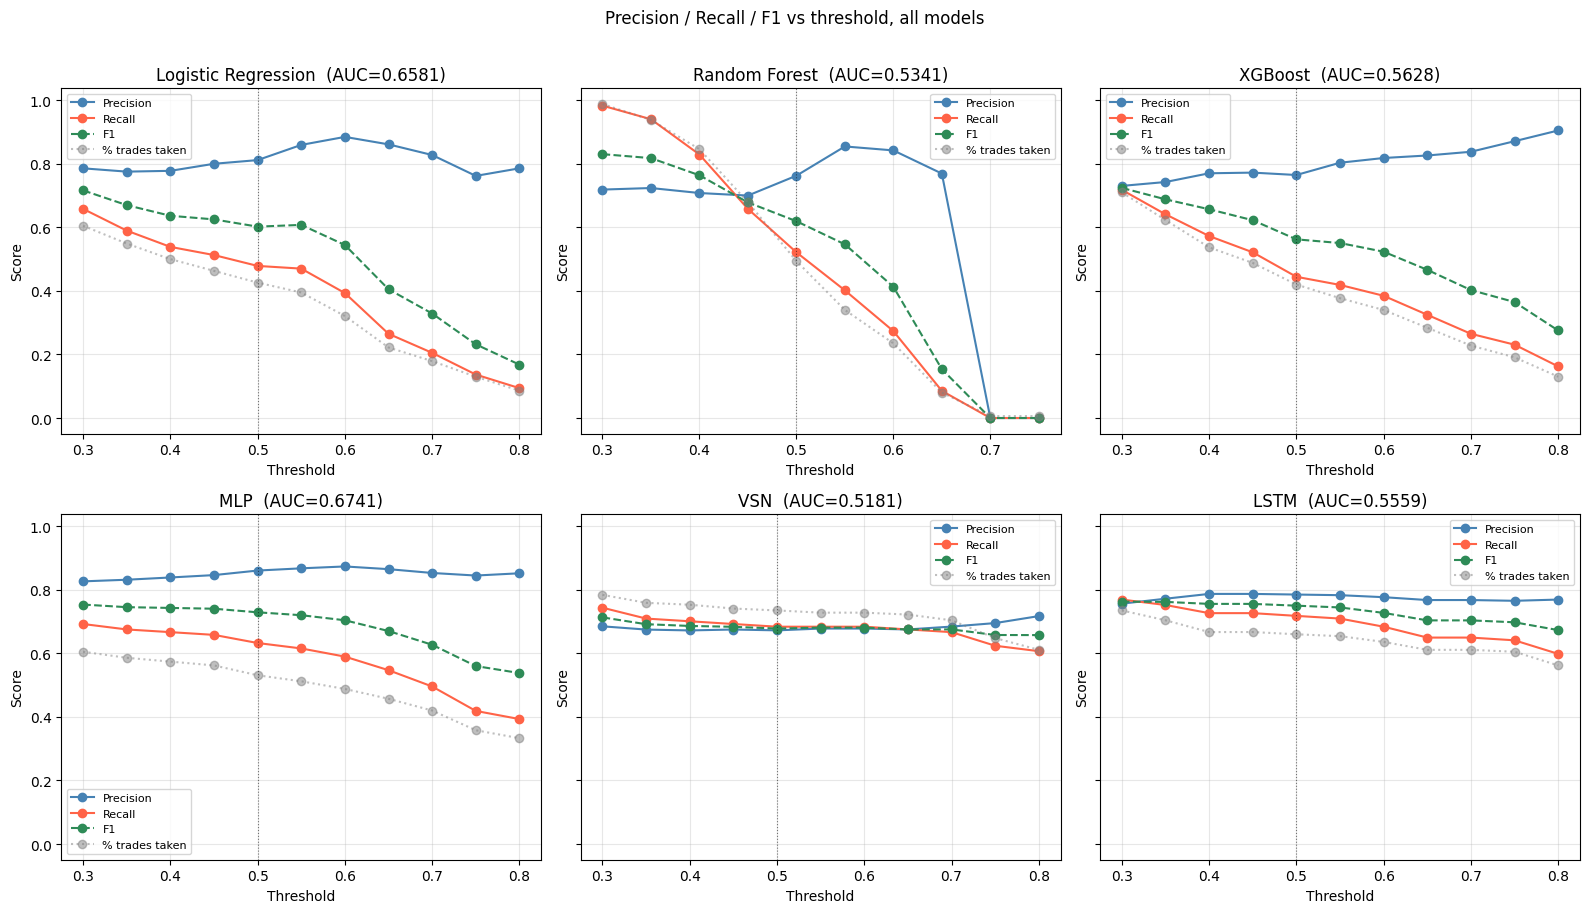

In [87]:
# -----------------------------------------------------------------------
# Plot precision and recall vs threshold for all models
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, (model_name, df) in zip(axes, all_results.items()):
    ax.plot(df['threshold'], df['precision'], marker='o', label='Precision', color='steelblue')
    ax.plot(df['threshold'], df['recall'],    marker='o', label='Recall',    color='tomato')
    ax.plot(df['threshold'], df['f1'],        marker='o', label='F1',        color='seagreen', linestyle='--')
    ax.plot(df['threshold'], df['pct_taken'] / 100,
            marker='o', linestyle=':', alpha=0.5, color='gray', label='% trades taken')
    ax.axvline(0.5, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_title(f'{model_name}  (AUC={df["auc"].iloc[0]:.4f})')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision / Recall / F1 vs threshold, all models', y=1.01)
plt.tight_layout()
plt.show()

For the winning model (namely, the MLP), we can report the highest AUC: 0.6741, confirming it indeed as a good choice.

## 12. Feature Importance Analysis

For the feature importance analysis we use the model selected in Section 10 as the winning model, in our case the MLP. The MLP is a neural network and therefore a black box with no native importance, so our primary tool is a clustered MDA, which permutes the Section 7 feature clusters and measures the drop in out-of-sample AUC. MDA is model agnostic, so we also run it on an alternative model from a different family, XGBoost, and check whether the two agree on the leading groups. Finally, because the MLP itself cannot be read directly, we report the gain of a tree fit on the same clusters as an interpretable cross-reference. Since each model input is a single cluster factor, every method reports importance directly at the cluster level.

### 12.1 Clustered MDA (Permutation Importance)

MDA measures importance by permuting a feature and seeing how much the AUC falls. We apply it at the cluster level by permuting each Section 7 cluster factor on the held-out test set, with the HMM state probabilities permuted together as one regime block, and we repeat each permutation several times to get a standard deviation. Because it only needs the model's predictions, it works directly on the already-fitted MLP without retraining. A larger drop means the model relies on that cluster more, a drop near zero or below means the cluster carries little usable out-of-sample signal.

#### Winning Model (MLP)

                    cluster  auc_drop    std
                   regime_2    0.1043 0.0222
                seasonality    0.0653 0.0243
                 hmm_regime    0.0415 0.0367
cross_sectional_seasonality    0.0308 0.0155
             energy_spreads    0.0303 0.0123
                implied_vol    0.0260 0.0288
                   signal_2    0.0169 0.0080
                     regime    0.0141 0.0182
                      trend    0.0126 0.0125
      returns_oscillators_2    0.0023 0.0074
                    returns   -0.0022 0.0079
                   regime_5   -0.0031 0.0085
                   regime_3   -0.0035 0.0091
           energy_spreads_2   -0.0038 0.0073
                   regime_4   -0.0065 0.0076
        returns_oscillators   -0.0111 0.0121
                     signal   -0.0124 0.0236


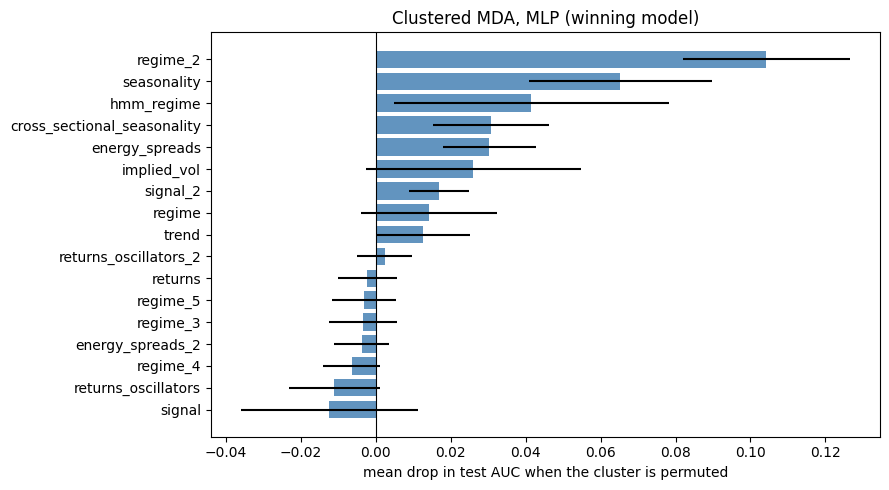

In [93]:
# Clustered permutation MDA: permute each section-7 cluster factor on the held-out test set
# and measure the drop in test AUC. It is model agnostic, so it works directly on the fitted
# MLP, which has no native importance. Each model input is one cluster, so this is importance
# at the cluster level. The HMM state probabilities are permuted together as one regime block.
cols = list(X_test_wti.columns)
hmm_idx = [i for i, c in enumerate(cols) if c.startswith('hmm_filt')]
mda_groups = {c: [i] for i, c in enumerate(cols) if not c.startswith('hmm_filt')}
if hmm_idx:
    mda_groups['hmm_regime'] = hmm_idx

def permutation_mda(proba_fn, X, y, groups, n_repeats=10, seed=42):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, proba_fn(X))
    rows = []
    for g, idx in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            for j in idx:
                Xp[:, j] = rng.permutation(Xp[:, j])
            drops.append(base - roc_auc_score(y, proba_fn(Xp)))
        rows.append({'cluster': g, 'auc_drop': np.mean(drops), 'std': np.std(drops)})
    return pd.DataFrame(rows).sort_values('auc_drop', ascending=False).reset_index(drop=True)

# Winning model: the MLP predicts on the scaled feature matrix X_te_sc.
mlp_proba_fn = lambda M: final_mlp.predict(M, verbose=0).flatten()
mda_mlp = permutation_mda(mlp_proba_fn, X_te_sc.copy(), y_te, mda_groups)
print(mda_mlp.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mda_mlp['cluster'][::-1], mda_mlp['auc_drop'][::-1],
        xerr=mda_mlp['std'][::-1], color='steelblue', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('mean drop in test AUC when the cluster is permuted')
ax.set_title('Clustered MDA, MLP (winning model)')
plt.tight_layout(); plt.show()

#### Alternative Model (XGBoost)

                    cluster     MLP  XGBoost
                   regime_2  0.1043   0.0101
                seasonality  0.0653   0.0000
                 hmm_regime  0.0415   0.0118
cross_sectional_seasonality  0.0308  -0.0297
             energy_spreads  0.0303   0.0151
                implied_vol  0.0260   0.0192
                   signal_2  0.0169   0.0006
                     regime  0.0141   0.0049
                      trend  0.0126  -0.0053
      returns_oscillators_2  0.0023   0.0393
                    returns -0.0022   0.0006
                   regime_5 -0.0031  -0.0021
                   regime_3 -0.0035   0.0379
           energy_spreads_2 -0.0038  -0.0030
                   regime_4 -0.0065  -0.0139
        returns_oscillators -0.0111   0.0070
                     signal -0.0124   0.0146


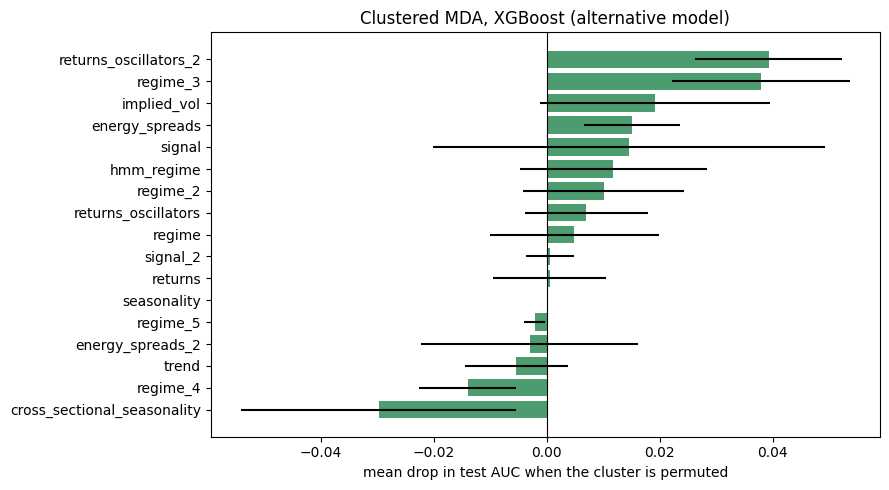

In [94]:
# Cross-check on a different model family (XGBoost). Agreement on the top clusters is
# evidence the signal is real and not a quirk of one model. XGBoost predicts on the
# unscaled cluster factors, so we pass X_test_wti rather than the scaled matrix.
xgb_proba_fn = lambda M: best_xgb.predict_proba(M)[:, 1]
mda_xgb = permutation_mda(xgb_proba_fn, X_test_wti.values.copy(), y_te, mda_groups)

compare = (mda_mlp[['cluster', 'auc_drop']].rename(columns={'auc_drop': 'MLP'})
           .merge(mda_xgb[['cluster', 'auc_drop']].rename(columns={'auc_drop': 'XGBoost'}), on='cluster'))
print(compare.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mda_xgb['cluster'][::-1], mda_xgb['auc_drop'][::-1],
        xerr=mda_xgb['std'][::-1], color='seagreen', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('mean drop in test AUC when the cluster is permuted')
ax.set_title('Clustered MDA, XGBoost (alternative model)')
plt.tight_layout(); plt.show()

### 12.2 Model-Native Cross-Reference (XGBoost Gain)

The MLP has no native importance to read, so for an interpretable cross-reference we use the gain of an XGBoost model fit on the same cluster factors. Gain is the boosting analog of MDI, it sums how much each feature improves the loss across the splits it appears in. It is computed in-sample, so we read it as a supplement to the out-of-sample MDA rather than on its own, and we expect it to overstate clusters that are split on frequently, such as the HMM states.

hmm_regime                     0.3062
signal                         0.0998
cross_sectional_seasonality    0.0810
returns_oscillators            0.0694
regime                         0.0595
regime_2                       0.0526
energy_spreads                 0.0477
regime_3                       0.0449
implied_vol                    0.0425
trend                          0.0396
returns_oscillators_2          0.0321
regime_4                       0.0305
signal_2                       0.0267
energy_spreads_2               0.0243
returns                        0.0241
regime_5                       0.0190
seasonality                    0.0000


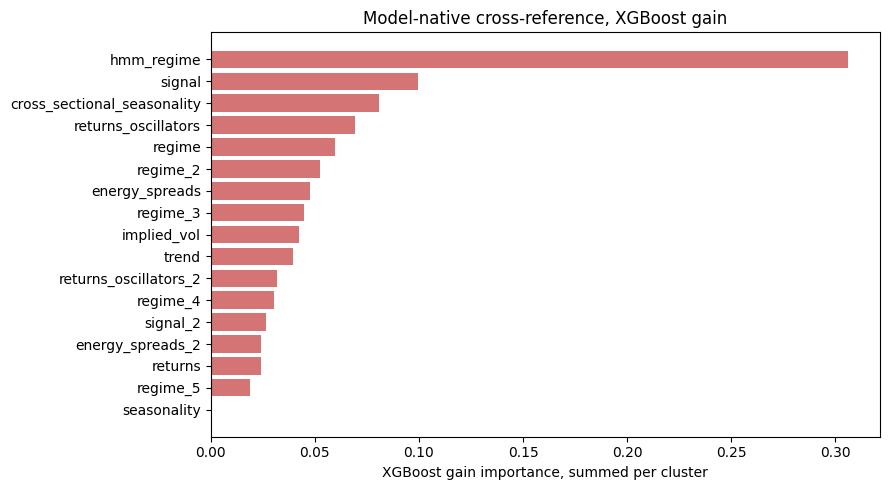

In [95]:
# The MLP cannot be read directly, so as an interpretable cross-reference we read the gain
# of the XGBoost model fit on the same cluster factors. Summed per cluster (HMM states summed
# into one regime block). Gain is in-sample, so compare it with the out-of-sample MDA above.
gain = pd.Series(best_xgb.feature_importances_, index=X_test_wti.columns)
gain_by_cluster = (pd.Series({g: gain.iloc[idx].sum() for g, idx in mda_groups.items()})
                   .sort_values(ascending=False))
print(gain_by_cluster.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(gain_by_cluster.index[::-1], gain_by_cluster.values[::-1], color='indianred', alpha=0.85)
ax.set_xlabel('XGBoost gain importance, summed per cluster')
ax.set_title('Model-native cross-reference, XGBoost gain')
plt.tight_layout(); plt.show()

### 12.3 Which Feature Groups Drive the Metamodel

We read three views together: the out-of-sample MDA on the winning MLP, the same MDA on the XGBoost cross-check, and the in-sample XGBoost gain. They build a layered picture, and the differences between them are as informative as the rankings themselves.

**Gain and MDA disagree** 

The XGBoost gain is overwhelmingly dominated by the HMM regime block (`hmm_regime`), at roughly 0.31, more than three times any other cluster. But when we permute that same block out of sample, its AUC drop is small, about 0.04 for the MLP and 0.01 for XGBoost. The HMM state probabilities are continuous and get split on constantly while the trees are grown, which inflates their in-sample gain, yet they barely improve out-of-sample prediction. This is the textbook weakness of MDI-style importance, and it is why we treat the out-of-sample MDA as the primary evidence and read the gain only as a cross-reference.

The clusters both models actually rely on out of sample are economically sensible. Three groups have a positive permutation drop for both the MLP and XGBoost:

* **Implied volatility** (`implied_vol`, the OVX z-score and slope). This acts as a trust dial for the primary signal. When OVX is high or rising, the options market is pricing stress, trend-following signals tend to get whipsawed, and the bet is worth less. When OVX is low and calm, the tape is cleaner and signals are more reliable.
* **The gasoline crack spread** (`energy_spreads`, RBOB minus crude). This is the gasoline refining margin, a proxy for physical product demand. A crude position backed by healthy refining margins is more likely to pay off than one taken while margins are collapsing. Interestingly, the composite 3-2-1 crack (`energy_spreads_2`) adds nothing for either model, so the simple gasoline crack already carries the demand information.
* **The market regime** (`hmm_regime`). Modest but positive for both, the broad calm-versus-turbulent state conditions how trustworthy a signal is.

Beyond that, the two models lean on different things, which we do not over-read.

The MLP relies most on regime age (`regime_2`, the days since the last regime switch) and the winter-season flag (`seasonality`), which are conditional and non-linear effects that a neural network can capture and that the tree did not pick up on this small sample. XGBoost instead keys off recent short-term momentum (`returns_oscillators_2`) and the volatility level (`regime_3`). Because these are not shared across the two models, we treat them as each model's particular way of fitting a noisy target rather than as robust drivers.

**Conclusion:** The magnitudes are small. The top MLP cluster drops AUC by about 0.10 and the top XGBoost cluster by about 0.04, with most clusters near zero. The two models agree on only three groups, and one of them, cross-sectional coherence with the driving-season flag (`cross_sectional_seasonality`), even flips sign between them, being positive for the MLP and negative for XGBoost. All of this is consistent with the modest out-of-sample AUC on WTI seen in sections 10 and 11. The fair reading is that the metamodel extracts a little genuine signal from how expensive options are, from refining margins, and from the market regime, but no single feature group is a strong, stable driver on this instrument. It is also worth noting that the primary signal's own direction (`signal_2`) adds almost nothing, which is expected because the metamodel is judging signal quality rather than direction.

## Exporting the predictions